# Connectomes

In [1]:
import gzip
import os
import shutil

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

In [2]:
mouse_net = nx.read_graphml("data/graphml/mouse_brain_1.graphml")
fly_net = nx.read_graphml("data/graphml/drosophila_medulla_1.graphml")

ParseError: syntax error: line 1, column 0 (<string>)

In [ ]:
if not os.path.exists('data/csv/connections_princeton.csv'):
    with gzip.open('data/csv/archive/connections_princeton.csv.gz', 'rb') as f_in:
        with open('data/csv/connections_princeton.csv', 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)


In [ ]:
if not os.path.exists('data/graphml/fafb_brain.graphml'):
    fafb_connections = pd.read_csv('data/csv/connections_princeton.csv', header=0)
    fafb_net = nx.from_pandas_edgelist(fafb_connections, source='pre_root_id', target='post_root_id', edge_key='neuropil', edge_attr=True, create_using=nx.MultiDiGraph()) # pyright: ignore[reportArgumentType, reportCallIssue]
else:
    fafb_net = nx.read_graphml("data/graphml/fafb_brain.graphml")

In [7]:
print(f"Number of nodes in Mouse: {mouse_net.number_of_nodes()}")
print(f"Number of edges in Mouse: {mouse_net.number_of_edges()}")

print(f"Number of nodes in Fly: {fly_net.number_of_nodes()}")
print(f"Number of edges in Fly: {fly_net.number_of_edges()}")

Number of nodes in Mouse: 213
Number of edges in Mouse: 21807
Number of nodes in Fly: 1781
Number of edges in Fly: 33641


In [11]:
print(f"Number of nodes in Female Adult Fly Brain: {fafb_net.number_of_nodes()}")
print(f"Number of edges in Female Adult Fly Brain: {fafb_net.number_of_edges()}")

Number of nodes in Female Adult Fly Brain: 138584
Number of edges in Female Adult Fly Brain: 5342446


In [ ]:
nx.write_graphml(fafb_net, "data/graphml/fafb_brain.graphml")

## Network Plot

In [ ]:
fig, ax = plt.subplots(figsize=(16, 10), dpi=300)

pos = nx.spring_layout(mouse_net, seed=42, k=1, iterations=50)
nx.draw_networkx_edges(mouse_net, pos, alpha=0.5, edge_color='gray', ax=ax)
nx.draw_networkx_nodes(mouse_net, pos, node_size=85, node_color='tab:blue', alpha=0.7, ax=ax)

ax.set_title("Mouse Brain Connectome", fontsize=16, pad=20, fontweight='bold')
fig.savefig("viz/mouse_brain_connectome.png")
plt.close(fig)

In [ ]:
fig, ax = plt.subplots(figsize=(16, 10), dpi=300)

pos = nx.spring_layout(fly_net, seed=42, k=1, iterations=50)
nx.draw_networkx_edges(fly_net, pos, alpha=0.5, edge_color='gray', ax=ax)
nx.draw_networkx_nodes(fly_net, pos, node_size=85, node_color='tab:blue', alpha=0.7, ax=ax)

ax.set_title("Fly Brain Connectome ", fontsize=16, pad=20, fontweight='bold')
fig.savefig("viz/fly_brain_connectome.png")
plt.close(fig)

## Network Level Properties

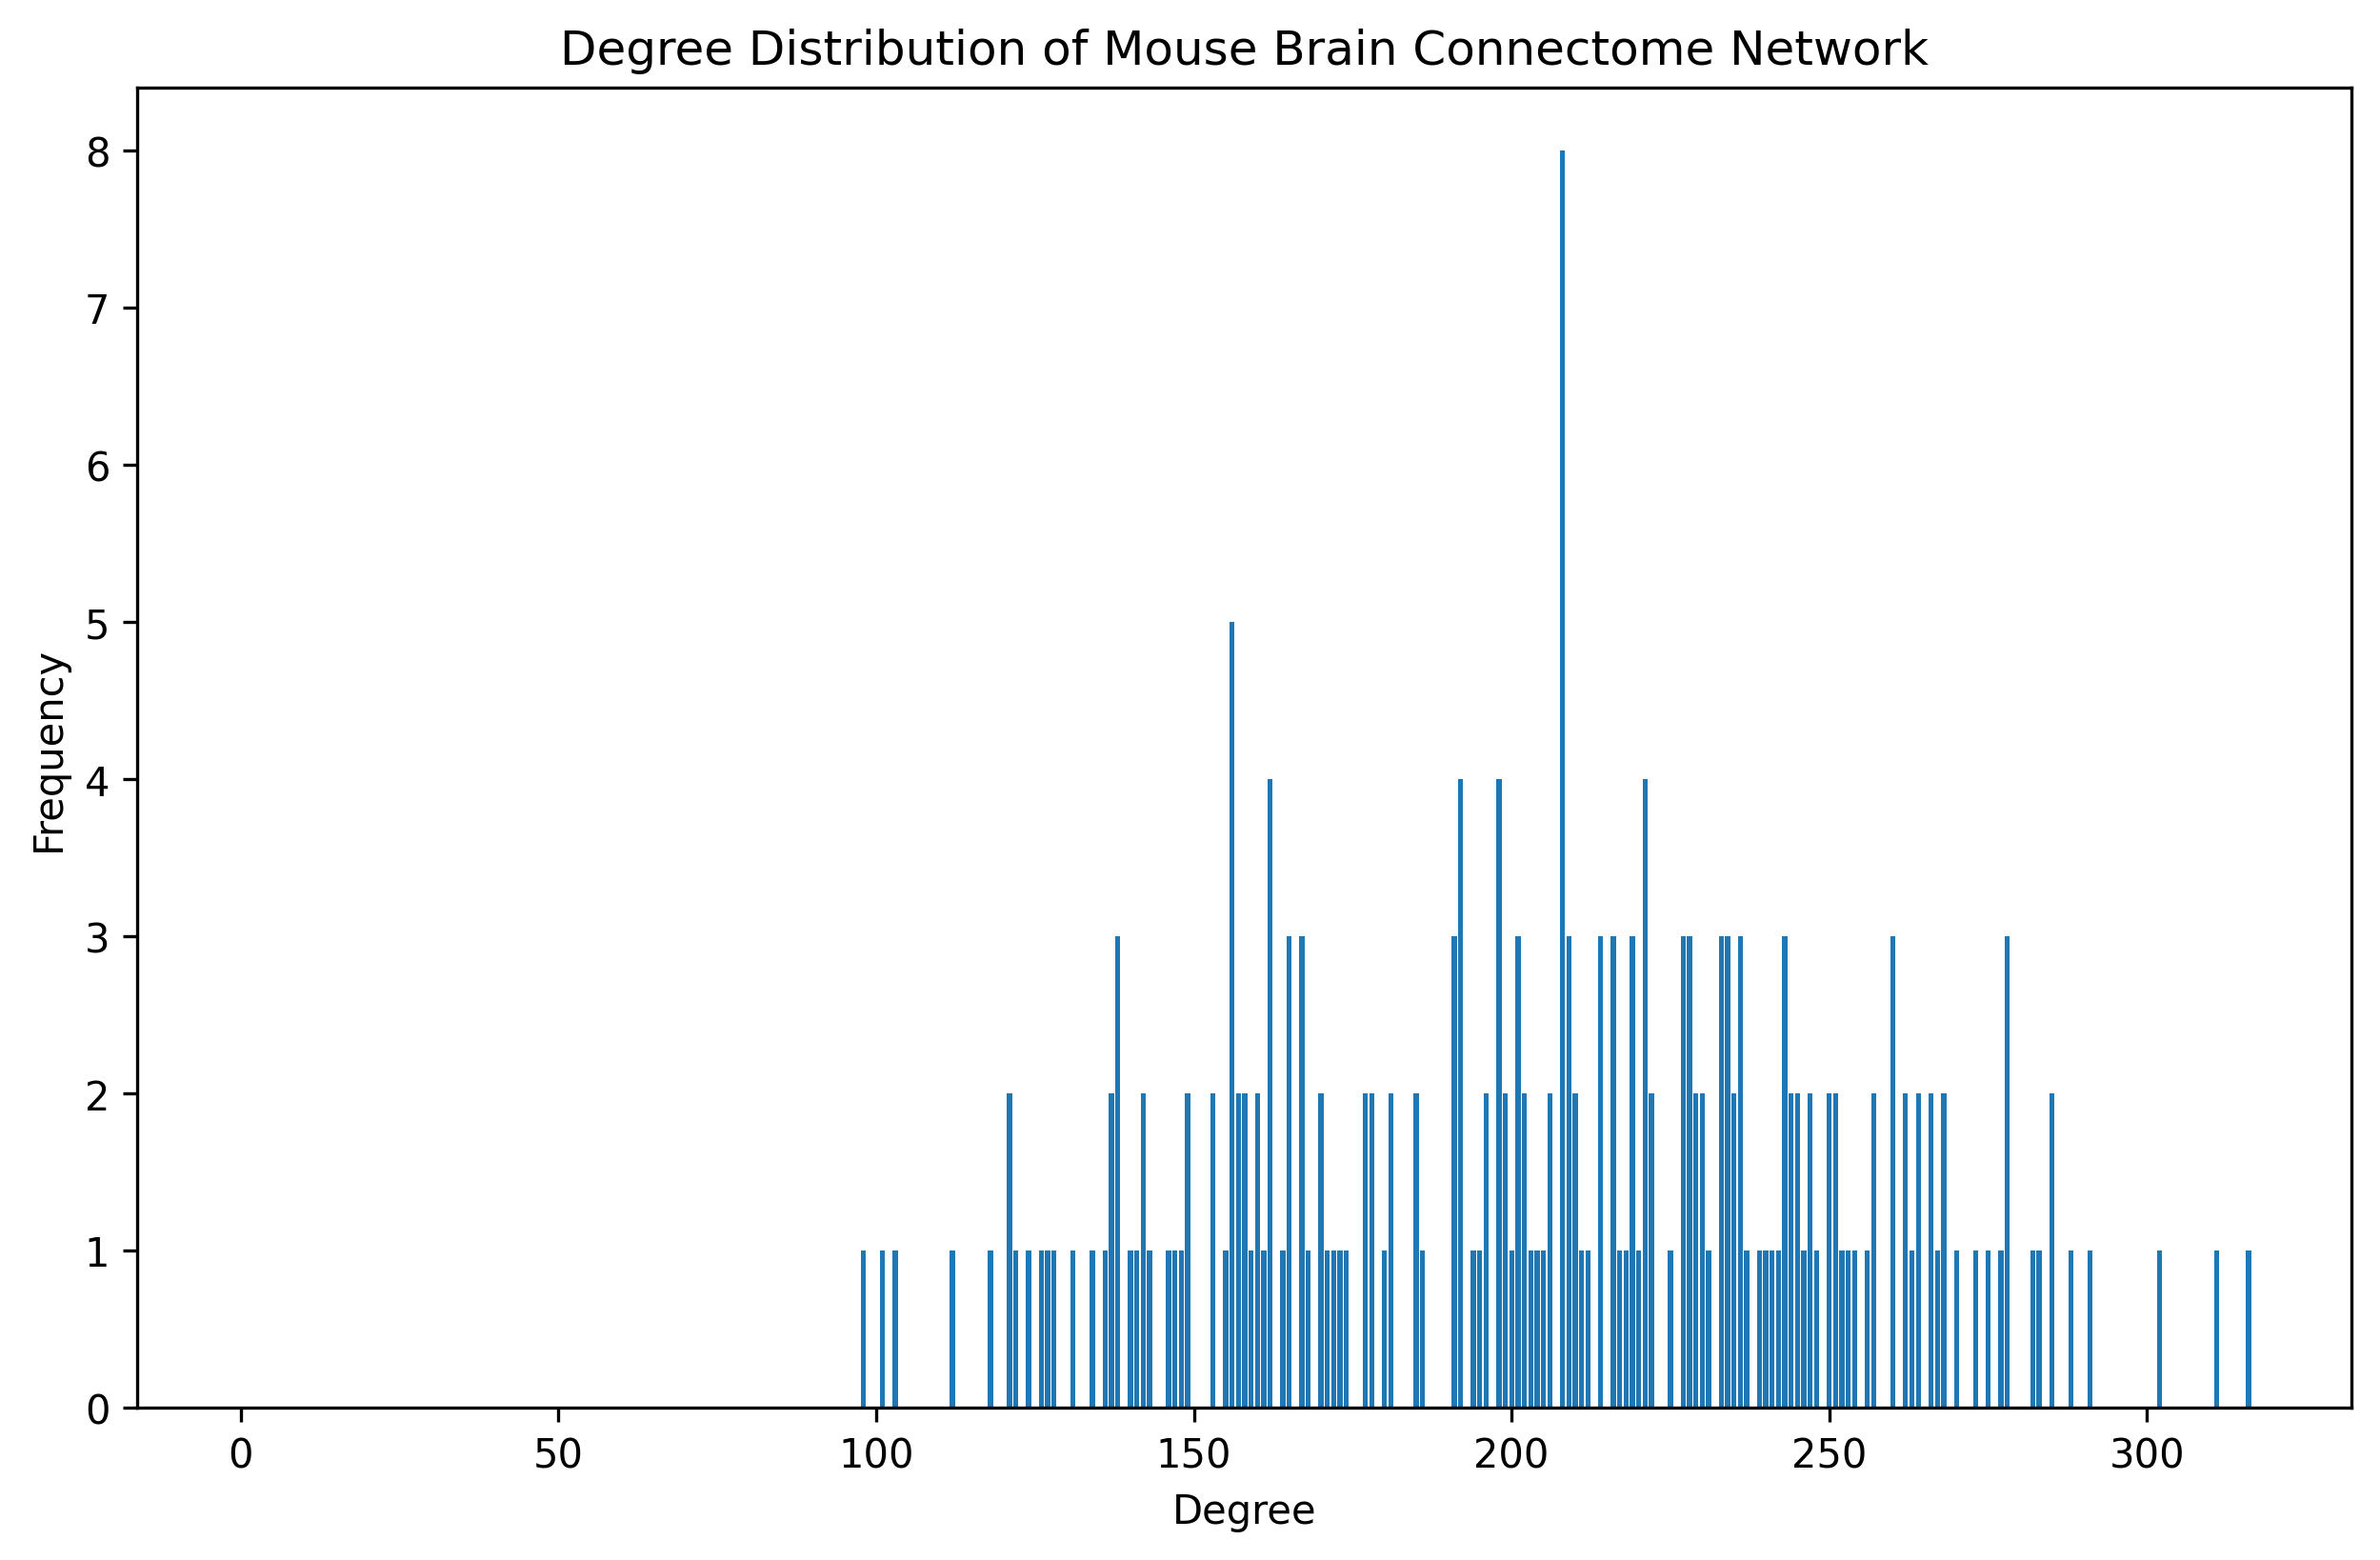

In [13]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
degree_sequence = sorted([d for n, d in mouse_net.degree()], reverse=True)
degree_count = np.bincount(degree_sequence)
degrees = np.arange(len(degree_count))
ax.bar(degrees, degree_count)
ax.set_xlabel("Degree")
ax.set_ylabel("Frequency")
# ax.set_xscale("log")
# ax.set_yscale("log")
ax.set_title("Degree Distribution of Mouse Brain Connectome Network")
plt.show(fig)

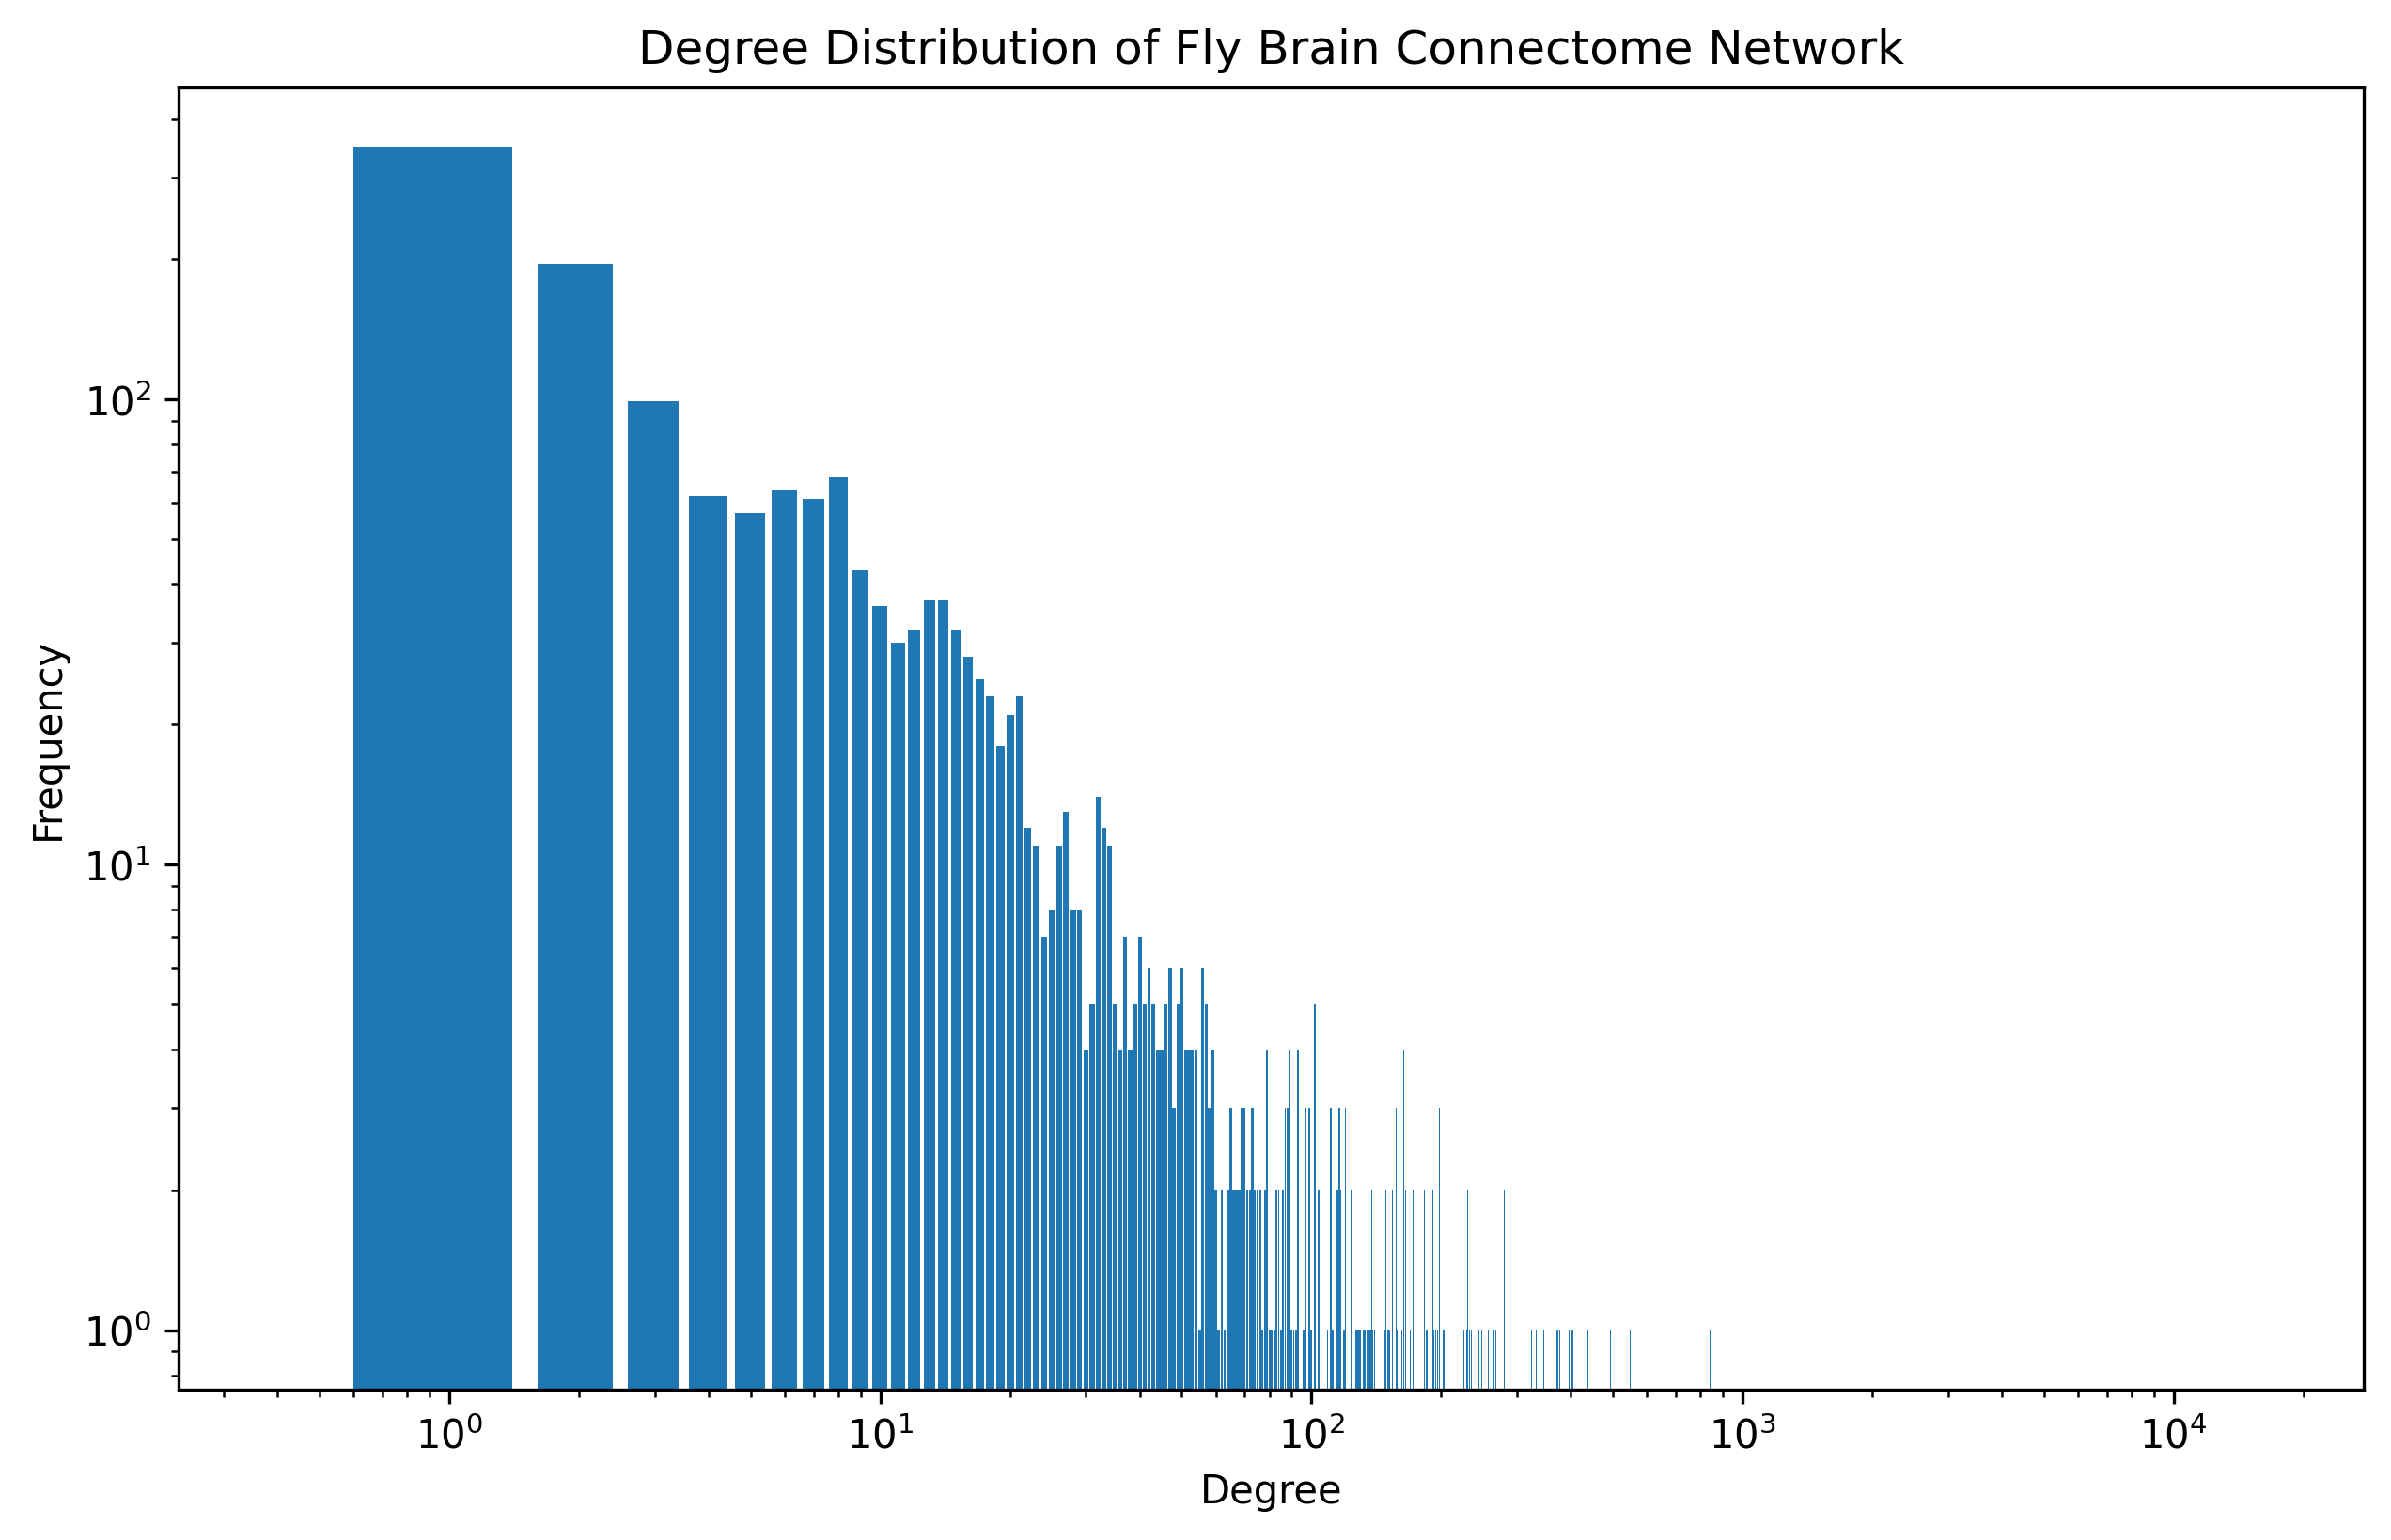

In [15]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
degree_sequence = sorted([d for n, d in fly_net.degree()], reverse=True)
degree_count = np.bincount(degree_sequence)
degrees = np.arange(len(degree_count))
ax.bar(degrees, degree_count)
ax.set_xlabel("Degree")
ax.set_ylabel("Frequency")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Degree Distribution of Fly Brain Connectome Network")
plt.show(fig)

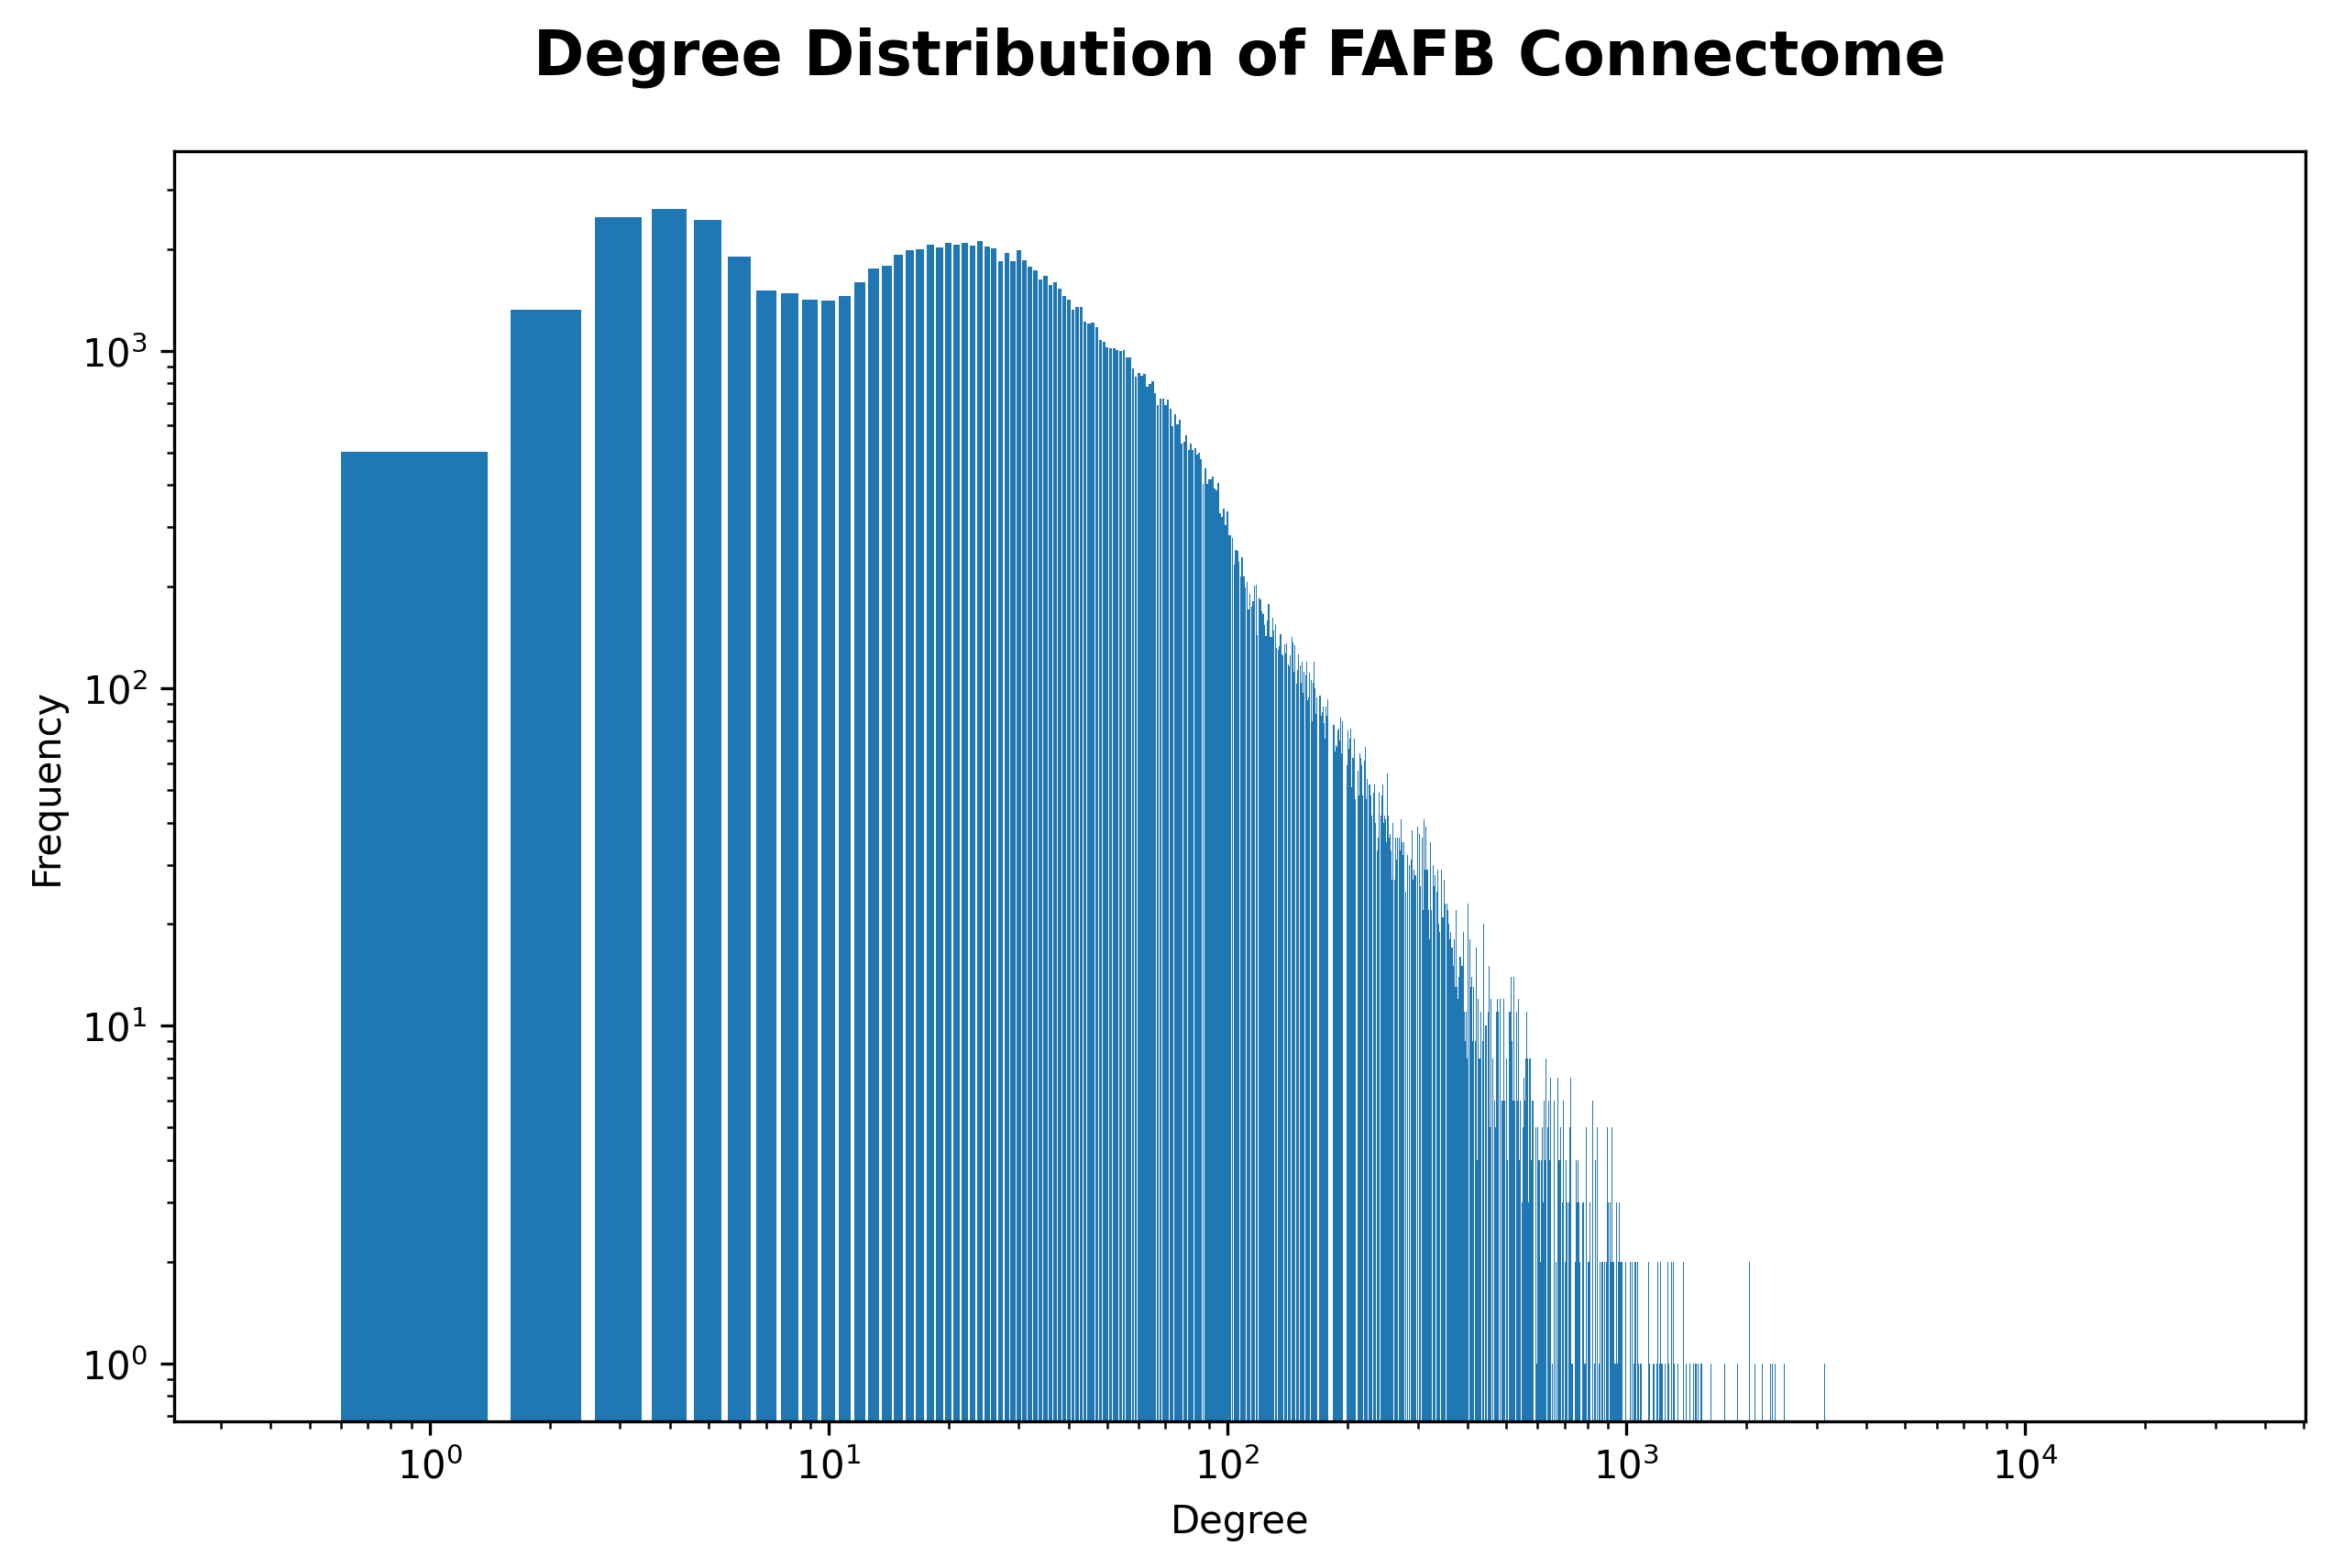

In [19]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
degree_sequence = sorted([d for n, d in fafb_net.degree()], reverse=True)
degree_count = np.bincount(degree_sequence)
degrees = np.arange(len(degree_count))
ax.bar(degrees, degree_count)
ax.set_xlabel("Degree")
ax.set_ylabel("Frequency")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Degree Distribution of FAFB Connectome", fontsize=16, pad=20, fontweight='bold')
plt.show(fig)